# Predict Notebook

### 1. Install libraries and model loading
In this section, we import the necessary libraries and load the pre-trained Machine Learning model (`.pkl` files) generated in the training notebook.

**Requirements:**
* `modelo_carbonatacao.pkl`: The trained regressor.
* `colunas_modelo.pkl`: The list of feature names to ensure correct input order.

In [3]:
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load model and columns
try:
    MODEL = joblib.load('modelo_carbonatacao.pkl')
    COLUMNS = joblib.load('colunas_modelo.pkl')
    print("Model loaded successfully.")
except FileNotFoundError:
    print("ERROR: .pkl files not found. Run the training notebook first.")

Model loaded successfully.


### 2. Prediction Function
Here we define the `predict_carbonation` function. It standardizes the inputs, handles categorical encoding (cement types and exposure conditions), and generates carbonation depth predictions for a continuous list of years.

In [4]:
def predict_carbonation(CCO2: float, fc: float, RH: float, 
                        type_of_cement: str, exposure_conditions: str, 
                        time_list: list) -> pd.DataFrame:
    """
    Predicts carbonation depth for a list of time steps based on environmental and material parameters.

    :param CCO2: CO2 concentration (%)
    :param fc: Concrete compressive strength (MPa)
    :param RH: Relative Humidity (%)
    :param type_of_cement: Cement type code as string (e.g., "2" for CPIV)
    :param exposure_conditions: Exposure condition code as string (e.g., "0" for PIA)
    :param time_list: List of years to simulate (e.g., [1, 2, ... 100])

    return: DataFrame containing 'Time (years)' and 'Predicted Carbonation (mm)'
    """
    
    # Convert categorical inputs to integers
    cement_code = int(type_of_cement)
    exposure_code = int(exposure_conditions)

    # Create input DataFrame for all time steps
    input_data = []
    for t in time_list:
        row = {
            'CCO₂ (%)': CCO2,
            'fc (MPa)': fc,
            'RH (%)': RH,
            'Type of cement': cement_code,
            'Exposure conditions': exposure_code,
            't (years)': t
        }
        input_data.append(row)

    # Crearte DataFrame and ensure correct column order
    df_input = pd.DataFrame(input_data)
    df_input = df_input[COLUMNS] 

    # Predict
    predictions = MODEL.predict(df_input)

    # Format results
    results = pd.DataFrame({
        'Time (years)': time_list,
        'Predicted Carbonation (mm)': predictions
    })

    return results

### 3. Simulation (Time History)

In [6]:
# Define Time History (1 to 100 years)
time_history = list(range(1, 101))

# Execute prediction with defined parameters
results_df = predict_carbonation(
    CCO2 = 0.28,
    fc = 36.0,
    RH = 42.9,
    type_of_cement = "2",       # CPIV
    exposure_conditions = "0",  # PIA
    time_list = time_history
)

print("Simulation complete. Visualizing the last 5 rows:")
display(results_df.tail())

results_df.to_excel("results_carbonation.xlsx", index=False)
print("Table saved to Excel successfully!")

Simulation complete. Visualizing the last 5 rows:


,Time (years),Predicted Carbonation (mm)
95,96,37.528893
96,97,37.566461
97,98,37.566461
98,99,37.655041
99,100,37.903443


Table saved to Excel successfully!


### 4. Plotting 

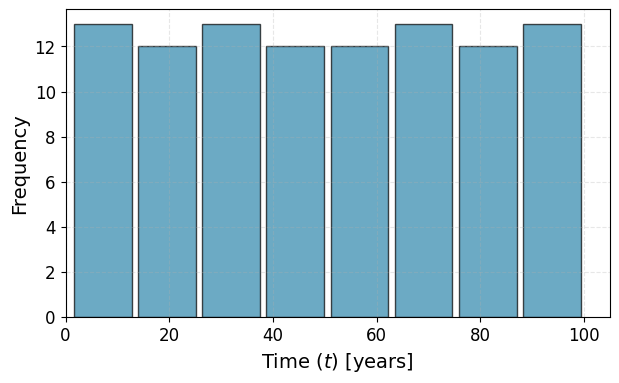

Graph saved: histogram_time_en.png


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_time_histogram(df: pd.DataFrame) -> None:
    """
    Plots a histogram of the Time variable (Exposure Duration).
    """
    # Dimensions
    width_cm, height_cm = 16, 10
    figsize = (width_cm / 2.54, height_cm / 2.54)
    
    # Colors and Sizes
    bar_color = '#2E86AB'
    axis_size, label_size = 12, 14
    
    xlabel = r'Time ($t$) [years]'
    ylabel = 'Frequency'
    filename = 'histogram_time_en.png'

    plt.figure(figsize=figsize)
    
    # Plotting Histogram 
    plt.hist(df['Time (years)'], 
             bins='auto', 
             color=bar_color, 
             edgecolor='k', 
             alpha=0.7, 
             rwidth=0.9)

    # Applying styles
    plt.tick_params(axis='both', which='major', labelsize=axis_size)
    plt.xlabel(xlabel, fontsize=label_size)
    plt.ylabel(ylabel, fontsize=label_size)
    
    # Optional: Force X-axis to show 0 to 100 if the data allows
    plt.xlim(0, 105) 
    
    # Grid and Layout
    plt.grid(alpha=0.3, linestyle='--')
    plt.tight_layout()
    
    # Save and Show
    plt.savefig(filename, dpi=300)
    plt.show()
    print(f"Graph saved: {filename}")

# Generate the Histogram of Time
plot_time_histogram(results_df)